In [ ]:
import sys
import os
import numpy as np
import pandas as pd
import datetime as dt   
import matplotlib.pyplot as plt
import norgatedata

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from data.data_loader import StooqDataLoader
from tqdm import tqdm


In [18]:
stooq_loader = StooqDataLoader()

start_date = dt.datetime(1995, 1, 1)
end_date = dt.datetime(2025, 10, 1)
symbol = "AAPL"

df = stooq_loader.load_data(symbol, start_date, end_date)
display(df.head())


2025-05-17 08:10:14 - INFO - Successfully loaded Stooq data for AAPL


,Open,High,Low,Close,Volume
Date,,,,,
1995-01-03,0.292416,0.292416,0.285006,0.288929,123268795
1995-01-04,0.290517,0.297887,0.290517,0.296449,188319092
1995-01-05,0.295197,0.296449,0.291550,0.292416,87393965
1995-01-06,0.313004,0.324467,0.309368,0.315981,1277706798
1995-01-09,0.313004,0.315092,0.308481,0.309989,325278429


In [37]:
# Get prices
df = norgatedata.price_timeseries(
    'AAPL',
    stock_price_adjustment_setting=norgatedata.StockPriceAdjustmentType.CAPITALSPECIAL,
    timeseriesformat='pandas-dataframe'
)


Past 3-day return on Jan-21st 2022: -4.4%
Return 5 days after Jan-21st 2022:  +6.4%


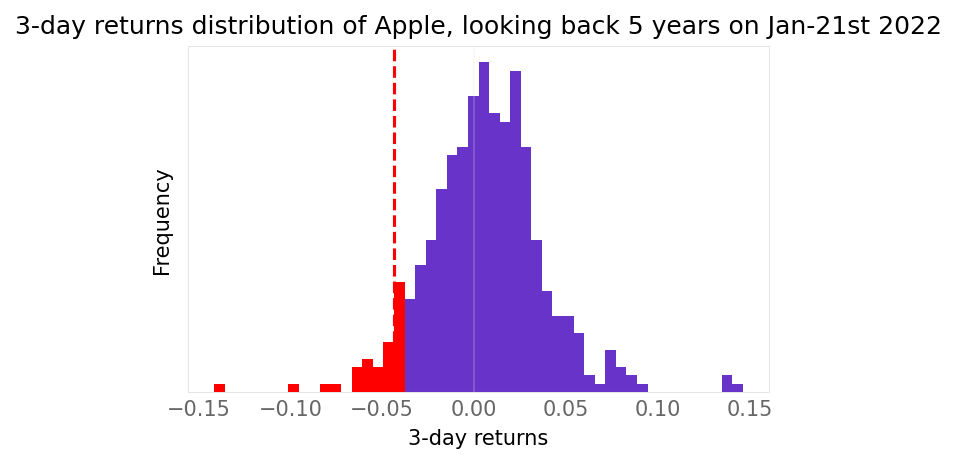

In [32]:
# Compute past 3-days returns
df['3d_bwd_return'] = df['Close'].pct_change(periods=3)
# Compute return after 5 days
df['5d_fwd_return'] = df['Close'].shift(-5) / df['Open'].shift(-1) - 1

# Filter the data for the past 5 years up to 2022-01-21
cutoff_date = np.datetime64('2022-01-21')
df = df.loc[df.index <= cutoff_date].tail(252 * 5)


data = df['3d_bwd_return']

x = data.iloc[-1]
color1, color2 = '#6833C9', 'red'

fig, ax = plt.subplots(figsize=(5, 3), dpi=150)
counts, bins, patches = ax.hist(data, bins=50)

for spine in ax.spines.values():
    spine.set_edgecolor('#E6E6E6')
    spine.set_linewidth(0.5)

for i in range(len(bins) - 1):
    if bins[i] <= x:
        plt.setp(patches[i], 'facecolor', color2)
    else:
        plt.setp(patches[i], 'facecolor', color1)

ax.axvline(x=x, color='red', linestyle='--')
ax.axvline(x=0, color='#E6E6E6', linestyle='-', linewidth=0.2)

ax.tick_params(axis='both', which='both', length=0)
ax.tick_params(axis='x', colors='#666666')
ax.tick_params(axis='y', colors='#666666')
ax.set_yticklabels([]);

plt.title('3-day returns distribution of Apple, looking back 5 years on Jan-21st 2022');
plt.xlabel('3-day returns');
plt.ylabel('Frequency');

print(f"Past 3-day return on Jan-21st 2022: {x:+.1%}")
print(f"Return 5 days after Jan-21st 2022:  {df['5d_fwd_return'].iloc[-1]:+.1%}")

In [33]:
# Get the percentile of the past -4.4% return
percentile = df['3d_bwd_return'].rank(pct=True).iloc[-1]  # to fetch the last one
# Get the probability of a price down move
probability_down = (df['3d_bwd_return'] <0).sum() / len(df)
# Compoute the probability of a price to drop -4.4% or more, conditioned that it was a drop 
qpi =  percentile / probability_down

print(f'Percentile for the -4.4%: {percentile:.1%}')
print(f'Probability of a price drop:     {probability_down:.1%}')
print(f'Probability of a drop -4.4% or larger, conditioned that it was a drop: {qpi:.1%}')

s = """
 
Summary of the analysis:
We see three numbers. This is what they mean:
When we look 5 years back from Jan-21st 2022, the past 3-day return (-4.4%) was the 4.8% percentile within all 1260 values. In other words, if we rank all these 1260 values, being 0 the lowest and 100 the largest, the value -4.4% would be the rank 4.8.
Looking back 5 years from this date, the probability of Apple showing a negative 3-day return was 40.8%.
Finally, the probability of a drop -4.4% or larger, conditioned that it was a drop, was 11.9%.
If we had bought Apple stock at the opening of the following day, and held for 5 days, we would have made +6.4%.
"""
print(s)

Percentile for the -4.4% return: 4.8%
Probability of a price drop:     41.0%
Probability of a drop -4.4% or larger, conditioned that it was a drop: 11.7%


Summary of the analysis:
We see three numbers. This is what they mean:
When we look 5 years back from Jan-21st 2022, the past 3-day return (-4.4%) was the 4.8% percentile within all 1260 values. In other words, if we rank all these 1260 values, being 0 the lowest and 100 the largest, the value -4.4% would be the rank 4.8.
Looking back 5 years from this date, the probability of Apple showing a negative 3-day return was 40.8%.
Finally, the probability of a drop -4.4% or larger, conditioned that it was a drop, was 11.9%.
If we had bought Apple stock at the opening of the following day, and held for 5 days, we would have made +6.4%.



### QPI 
The idea behind the QPI is to measure how probable a price change of that magnitude or more extreme is, in a window of N days, looking back at Y years from the date in question.

Let's set a default window N of 3 days, as we want to capture short-term mean reversion, and a default look back of 5 years to retrieve the 3-day returns histogram. So, to compute 
the QP indicator for the stock S on a given date:

1. We look back 5 years from the given date and get all 3-day returns in this period;
2. Then, we get the percentile of the 3-day price change on the given date if the 3-day     price change is negative (or 100 minus the percentile if the 3-day price change is positive);
3. Finally, we divide this value by the area at the left of the zero in the histogram if the 3-day price change is negative (or at the right if it is positive) and multiply by 100.
That's it. 

This number will vary between 0 and 100. The closer it is to zero, the rarer the event. The closer it is to 100, the more common the price change.


In [38]:
def qp_indicator_unvectorized(close, window=3, lookback_years=5):
    """
    For each date (starting after lookback_years of history):
    Look back lookback_years worth of data (≈252 trading days/year).
    Compute N-day (window) percentage returns over the lookback period.
    Get the most recent N-day return (value) ending at the current date.
    Calculate the percentile rank of this return within the historical returns.
    Normalize the percentile based on the probability of returns in the same direction:
    If the return is ≤ 0, divide its percentile by the fraction of returns ≤ 0
    If the return is > 0, divide (1 - percentile) by the fraction of returns > 0.
    """
    def percentile_rank(series, value):
        rank = series.rank(pct=True)
        percentile = rank[series == value].iloc[0]
        return percentile
    
    result = pd.Series(index=close.index)
    for date in close.index[252 * lookback_years:]:
        p = close.loc[close.index <= date].iloc[-252 * lookback_years - 1:]
        if len(p) < 252 * lookback_years:
            continue

        rets = p.pct_change(periods=window).dropna()
        value = rets.iloc[-1]
        rank = percentile_rank(rets, value)

        if value <= 0:
            prob_down = len(rets[rets <= 0]) / len(rets)
            result.loc[date] = rank / prob_down
        else:
            prob_up = len(rets[rets > 0]) / len(rets)
            result.loc[date] = (1 - rank) / prob_up
    
    return result * 100


def qp_indicator_vectorized(close, window=3, lookback_years=5):
    def rolling_rank(x):
        return (x.rank(pct=True).iloc[-1])

    try:
        rets = close.pct_change(periods=window)
    except ValueError as e:
        return pd.Series(index=close.index)

    rolling_rank = rets.rolling(window=lookback_years * 252).apply(rolling_rank, raw=False)
    rolling_down = rets.rolling(window=lookback_years * 252).apply(lambda x: (x <= 0).sum())
    prob_down = rolling_down / (lookback_years * 252)
    prob_up = 1 - prob_down

    idx_down = rets[rets <= 0].index
    idx_up = rets[rets > 0].index

    qp = pd.Series(index=close.index)
    qp.loc[idx_down] = rolling_rank / prob_down
    qp.loc[idx_up] = (1 - rolling_rank) / prob_up
    qp *= 100
    return qp



In [39]:
df['qpi1'] = qp_indicator_unvectorized(df['Close'])
df['qpi2'] = qp_indicator_vectorized(df['Close'])
df.dropna(inplace=True)
assert np.allclose(df['qpi1'], df['qpi2'], atol=0.5)


In [40]:
def get_events_from_symbol(symbol, qp_window=3, fwd_return_window=5, start_date='1998-01-01', add_target=True, sma_window=200):
    df = norgatedata.price_timeseries(
        symbol,
        stock_price_adjustment_setting=norgatedata.StockPriceAdjustmentType.CAPITALSPECIAL,
        start_date=start_date,
        timeseriesformat='pandas-dataframe',
    )[['Open', 'Close', 'Turnover']]
    if len(df) == 0:
        return None

    df['symbol'] = symbol
    df['bwd_return'] = df['Close'].pct_change()
    df[f'{qp_window}d_bwd_return'] = df['Close'].pct_change(periods=qp_window)
    df['qp_indicator'] = qp_indicator_vectorized(df['Close'], window=qp_window, lookback_years=5)
    df['sma_200'] = df['Close'].rolling(window=sma_window).mean()

    if add_target:
        df['next_open'] = df['Open'].shift(-1)
        df[f'{fwd_return_window}d_fwd_close'] = df['Close'].shift(-fwd_return_window)
        df['return'] = df[f'{fwd_return_window}d_fwd_close'] / df['next_open'] - 1

    return df

In [41]:
symbols = norgatedata.watchlist_symbols('S&P 500 Current & Past')

results = []
for symbol in tqdm(symbols):
    res = get_events_from_symbol(symbol)
    if res is not None:
        results.append(res)

data = pd.concat(results)

events = data[
    (data['qp_indicator'] < 15)
    & (data['3d_bwd_return'] < 0)
    & (data['Close'] > data['sma_200'])
]

100%|██████████| 1275/1275 [08:02<00:00,  2.64it/s]


In [43]:
events

,Open,Close,Turnover,symbol,bwd_return,3d_bwd_return,qp_indicator,sma_200,next_open,5d_fwd_close,return
Date,,,,,,,,,,,
2006-05-16,24.424181,23.480900,336494176.0,A,-0.082170,-0.098785,4.368932,23.059290,23.447212,23.238346,-0.008908
2006-05-17,23.447212,23.440475,152637648.0,A,-0.001722,-0.066040,13.893376,23.087184,23.561754,22.989048,-0.024307
2006-05-18,23.561754,23.474163,109275664.0,A,0.001437,-0.082434,8.387097,23.114842,23.548279,22.847557,-0.029757
2007-03-01,22.274954,22.482330,91471376.0,A,-0.009764,-0.055288,14.586710,22.401769,22.417973,22.696856,0.012440
2007-08-09,27.816877,25.664465,191832048.0,A,-0.067308,-0.063169,8.305085,25.096589,26.172176,23.440544,-0.104372
...,...,...,...,...,...,...,...,...,...,...,...
2024-02-14,185.190002,184.080002,501555168.0,ZTS,0.003215,-0.067099,4.151625,179.965600,183.860001,196.660004,0.069618
2024-03-04,189.610001,187.860001,706099072.0,ZTS,-0.015512,-0.060418,5.605787,180.628200,187.440002,183.490005,-0.021073
2024-03-05,187.440002,185.229996,465435296.0,ZTS,-0.014000,-0.066052,4.512635,180.659650,185.300003,181.350006,-0.021317


In [44]:
def get_positive_negative_events(df, return_column='return'):
    all = df[return_column].describe()
    pos = df[df[return_column] >= 0][return_column].describe()
    neg = df[df[return_column] < 0][return_column].describe()
    t1 = pd.DataFrame()
    t1['All events'] = all
    t1['Positive events'] = pos
    t1['Negative events'] = neg

    new_row = {
        'All events': 1,
        'Positive events': pos['count'] / all['count'],
        'Negative events': neg['count'] / all['count']
    }
    index = t1.index.tolist()
    rows = t1.to_dict('records')
    rows.insert(1, new_row)
    index.insert(1, '%')
    return pd.DataFrame(rows, index=index)

get_positive_negative_events(events, return_column='return')

,All events,Positive events,Negative events
count,84192.000000,47044.000000,37148.000000
%,1.000000,0.558770,0.441230
mean,0.005700,0.038938,-0.036392
std,0.088707,0.101706,0.039544
min,-0.672131,0.000000,-0.672131
25%,-0.020955,0.012870,-0.048239
50%,0.005321,0.027591,-0.025066
75%,0.031250,0.049546,-0.011175
max,19.000000,19.000000,-0.000025


What we are seeing here ?
1. We have 84K of events.
2. The expectancy return is +5.7%.
3. Winrate is around 55.8%.
4. Each positive return event gets us 3.89% while negative -3.63%

### Lets check if its a really edge

In [45]:
# lets us compare the results we got with a distribution of returns from our entery signals where our entry signals were not met.
# then we can compare the return distribution of the events with the return distribution of the non-events.
# this is a good way to see if the events are statistically significant.

non_events = data[
    (data['qp_indicator'] > 15)
    & (data['3d_bwd_return'] < 0)
    & (data['Close'] > data['sma_200'])
]
get_positive_negative_events(non_events)

,All events,Positive events,Negative events
count,950584.000000,520217.000000,430367.000000
%,1.000000,0.547260,0.452740
mean,0.003117,0.029410,-0.028665
std,0.043558,0.034634,0.029919
min,-0.759184,0.000000,-0.759184
25%,-0.017444,0.009743,-0.038342
50%,0.003184,0.021174,-0.020108
75%,0.023526,0.038787,-0.008893
max,7.858273,7.858273,-0.000005


In [ ]:
# two-sample t-test to determine if the means of two independent samples are significantly different
# rememeber events (trades taken based on the strategy's entry condition) and nonevents (trades taken when the entry condition was not met)—are significantly different. 
# alternatively, we can use different tests such as Mann-Whitney U Test or Kolmogorov-Smirnov (KS) Test
from scipy import stats

t_stat, p_value = stats.ttest_ind(
    events['return'].dropna(), 
    non_events['return'].dropna()
)

print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.2e}")

# Check the result
alpha = 0.05
if p_value < alpha:
    print("The means of the two distributions are significantly different.")
    print("We have an edge !")
else:
    print("The means of the two distributions are not significantly different.")


T-statistic: 14.72
P-value: 5.03e-49
The means of the two distributions are significantly different.
Reject the null hypothesis (p-value: 5.03e-49)
We have an edge !


#### Another way to asses an edge !

In [52]:
# common method for assessing the predictive power of a signal (QPI) is to analyze returns across different quantiles. 
# by dividing the signal into quantiles and comparing the average return within each group, 
# we can gain insights into how the signal correlates with future performance

step = 5
intervals = [(i, i + step) for i in range(0, 100, step)]

brackets = []
for interval in intervals:
    e = data[
        (data['qp_indicator'] >= interval[0])
        & (data['qp_indicator'] < interval[1])
        & (data['3d_bwd_return'] < 0)
        & (data['Close'] > data['sma_200'])
    ]
    st = get_positive_negative_events(e)
    win_ratio = st.loc['%', 'Positive events']
    st = st['All events']
    st['%'] = win_ratio
    st = st.rename({'%': 'win ratio'})
    st.name = str(interval)
    brackets.append(st)

brackets = pd.concat(brackets, axis=1)
brackets.T

,count,win ratio,mean,std,min,25%,50%,75%,max
"(0, 5)",19816.0,0.553896,0.004832,0.065564,-0.573743,-0.023337,0.005200,0.033301,1.674286
"(5, 10)",29314.0,0.562223,0.006808,0.127181,-0.571429,-0.020507,0.005624,0.031754,19.000000
"(10, 15)",35062.0,0.558639,0.005265,0.054233,-0.672131,-0.019828,0.005090,0.029891,1.549569
"(15, 20)",38948.0,0.561467,0.004883,0.049093,-0.664815,-0.019079,0.005042,0.028724,0.789474
"(20, 25)",42070.0,0.552745,0.004053,0.047726,-0.759184,-0.019065,0.004190,0.027076,1.333333
"(25, 30)",45238.0,0.554711,0.003969,0.053230,-0.380531,-0.018501,0.004148,0.026075,4.000000
"(30, 35)",47518.0,0.555579,0.003720,0.046230,-0.692308,-0.018144,0.004197,0.026164,1.413793
"(35, 40)",49779.0,0.555094,0.003740,0.043366,-0.467391,-0.017677,0.003978,0.025252,0.706030
"(40, 45)",52513.0,0.552873,0.003558,0.043565,-0.591603,-0.017667,0.003813,0.024508,0.737354
"(45, 50)",54130.0,0.551229,0.003442,0.042540,-0.591165,-0.017571,0.003590,0.024362,0.568465


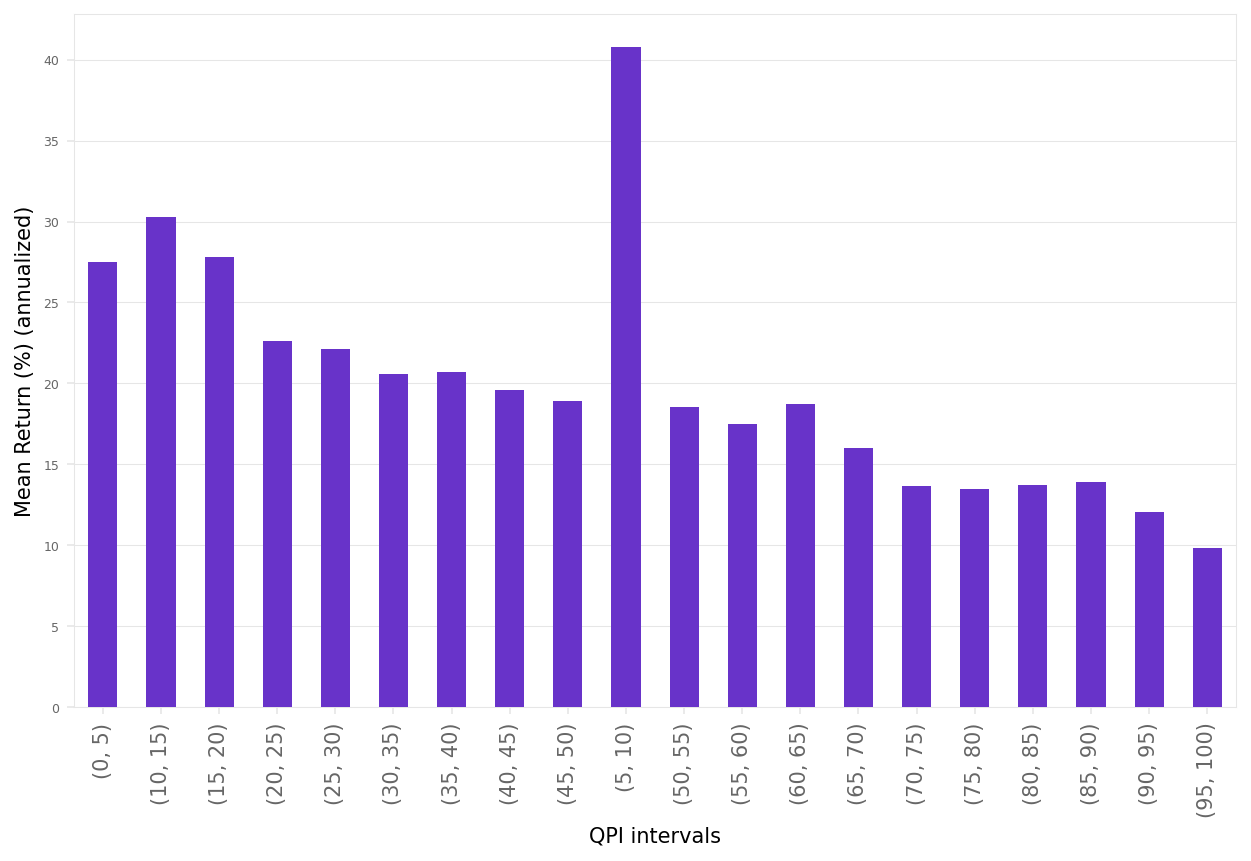

In [58]:
# lets visualize the results
xx = brackets.T['mean']
xx = xx.sort_index(level=1, ascending=True)
xx = ((xx + 1) ** (252 / 5) - 1) * 100
xx.index.name = xx.name = 'QPI intervals'

fig, ax = plt.subplots(1, 1, dpi=150, figsize=(10, 6))
xx.plot(kind='bar', ax=ax, color=['#6833C9'], zorder=10)

ax.set_ylabel('Mean Return (%) (annualized)')

for spine in ax.spines.values():
    spine.set_edgecolor('#E6E6E6')
    spine.set_linewidth(0.5)

ax.tick_params(axis='x', colors='#666666')
ax.tick_params(axis='y', colors='#666666')
ax.tick_params(axis='y', which='both', color='#e6e6e6', labelsize=6)
ax.tick_params(axis='x', which='both', color='#e6e6e6')
ax.grid(which='major', linestyle='-', linewidth='0.5', color='#e6e6e6', zorder=0, axis='y')